# Set data directory

In [1]:
path = './data/'
#path = '../publication/dltest/' ## THIS IS ONLY FOR TESTING

# Preamble

Install the necessary packages:

In [2]:
"""
%pip install tol-colors
%pip install git@github.com:imagdau/aseMolec.git
%pip install ase
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install pyyaml
%pip install scipy
%pip install requests
%pip install pathlib
%pip install joblib
"""

'\n%pip install tol-colors\n%pip install git@github.com:imagdau/aseMolec.git\n%pip install ase\n%pip install pandas\n%pip install numpy\n%pip install matplotlib\n%pip install pyyaml\n%pip install scipy\n%pip install requests\n%pip install pathlib\n%pip install joblib\n'

In [3]:
import funcs as funcs
from ase.io import read, iread
import ase.units
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa
import pandas as pd
import numpy as np
import tol_colors as tc
cset = tc.tol_cset('bright')
plt.rc('axes', prop_cycle=plt.cycler('color', list(cset)))


tags = [
    'Clusters-Small/wB97XD3/SEED1/DSET1',
    'Clusters-Small/wB97XD3/SEED1/DSET2',
    'Clusters-Small/wB97XD3/SEED1/DSET3',
    'Clusters-Small/B97D3/SEED1/DSET1',
    'Clusters-Small/B97D3/SEED1/DSET2',
    'Clusters-Small/B97D3/SEED1/DSET3',
    'Clusters-Small/wB97XD3/SEED2/DSET1',
    'Clusters-Small/wB97XD3/SEED3/DSET1',
    'Clusters-Medium/wB97XD3/SEED1/DSET1',
    'Clusters-Medium/wB97XD3/SEED1/DSET2',
    'Clusters-Medium/wB97XD3/SEED1/DSET3',
    'Clusters-Medium/B97D3/SEED1/DSET1',
    'Clusters-Medium/B97D3/SEED1/DSET2',
    'Clusters-Medium/B97D3/SEED1/DSET3',
    'Clusters-Medium/wB97XD3/SEED2/DSET1',
    'Clusters-Medium/wB97XD3/SEED3/DSET1',
    'Clusters-Large/wB97XD3/SEED1/DSET1',
    'Clusters-Large/wB97XD3/SEED2/DSET1',
    'Clusters-Large/wB97XD3/SEED3/DSET1',
]


small_pkl = './clusters-small_xyz.pkl'
medium_pkl = './clusters-medium_xyz.pkl'
large_pkl = './clusters-large_xyz.pkl'

scale = 2.5
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

/tmp/ipykernel_2068550/3770643439.py:12: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('bright')


In [4]:
label_map = {
    'B97D3':'B97-D3',
    'wB97XD3':'wB97X-D3',
}

comp_map = {
    '000conEC':'EMC',
    '033conEC':'EC:EMC (3:7)',
    '066conEC':'EC:EMC (7:3)',
    '100conEC':'EC',
}

traj_map = {
    'npt_000conEC_298K':'EMC',
    'npt_033conEC_298K':'EC:EMC (3:7)',
    'npt_066conEC_298K':'EC:EMC (7:3)',
    'npt_100conEC_313K':'EC',
}

# Download
## MLIP data

In [5]:
funcs.download_unpack(path, "clusters_metadata.yaml", "MLIP downloads")

./data/MLIP_MACE_Clusters-Small_B97D3.zip
Unzipping ./data/MLIP_MACE_Clusters-Small_B97D3.zip -> ./data/Clusters-Small/B97D3


./data/MLIP_MACE_Clusters-Small_wB97XD3.zip
Unzipping ./data/MLIP_MACE_Clusters-Small_wB97XD3.zip -> ./data/Clusters-Small/wB97XD3


./data/MLIP_MACE_Clusters-Medium_B97D3.zip
Unzipping ./data/MLIP_MACE_Clusters-Medium_B97D3.zip -> ./data/Clusters-Medium/B97D3


./data/MLIP_MACE_Clusters-Medium_wB97XD3.zip
Unzipping ./data/MLIP_MACE_Clusters-Medium_wB97XD3.zip -> ./data/Clusters-Medium/wB97XD3


./data/MLIP_MACE_Clusters-Large_wB97XD3.zip
Unzipping ./data/MLIP_MACE_Clusters-Large_wB97XD3.zip -> ./data/Clusters-Large/wB97XD3


## MD simulation data

In [6]:
funcs.download_unpack(path, "clusters_metadata.yaml", "MDSims downloads")

./data/MDSims_1000atoms_1ns_Clusters-Small_B97D3.zip
Unzipping ./data/MDSims_1000atoms_1ns_Clusters-Small_B97D3.zip -> ./data/Clusters-Small/B97D3


./data/MDSims_1000atoms_1ns_Clusters-Small_wB97XD3.zip
Unzipping ./data/MDSims_1000atoms_1ns_Clusters-Small_wB97XD3.zip -> ./data/Clusters-Small/wB97XD3


./data/MDSims_1000atoms_1ns_Clusters-Medium_B97D3.zip
Unzipping ./data/MDSims_1000atoms_1ns_Clusters-Medium_B97D3.zip -> ./data/Clusters-Medium/B97D3


./data/MDSims_1000atoms_1ns_Clusters-Medium_wB97XD3.zip
Unzipping ./data/MDSims_1000atoms_1ns_Clusters-Medium_wB97XD3.zip -> ./data/Clusters-Medium/wB97XD3


./data/MDSims_1000atoms_1ns_Clusters-Large_wB97XD3.zip
Unzipping ./data/MDSims_1000atoms_1ns_Clusters-Large_wB97XD3.zip -> ./data/Clusters-Large/wB97XD3


## Data overview

In [7]:
meta_df = funcs.yaml_to_multidf("clusters_metadata.yaml", ["Labels", "Parent data", "Data set"])
meta_df

Subset  Seeds  Number of structures  \
Labels   Parent data     Data set                                               
wB97X-D3 Clusters-Full   Clusters-Large        1      3                221824   
         Clusters-Large  Clusters-Medium       1      3                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      3                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   
B97-D3   Clusters-Large  Clusters-Medium       1      1                 42824   
                         Clusters-Medium       2      1                 42824   
                         Clusters-Medium       3      1                 42824   
         Clusters-Medium Clusters-Small        1      1                  8016   
                         Clusters-Small        2      1                  8016   
                         Clusters-Small        3      1                  8016   

                                          Number of atoms  
Labels   Parent data     Data set                          
wB97X-D3 Clusters-Full   Clusters-Large           4805916  
         Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089  
B97-D3   Clusters-Large  Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
                         Clusters-Medium          1269916  
         Clusters-Medium Clusters-Small            327089  
                         Clusters-Small            327089  
                         Clusters-Small            327089

___
# Results
## NPT dynamics
Load MD output files:

In [8]:
thermo = dict()
for tag in tags:
    thermo[tag] = funcs.get_all_thermo(f'{path}{tag}/dynamics/*', handle='.thermo')

./data/Clusters-Small/wB97XD3/SEED1/DSET1/dynamics/npt_033conEC_298K.thermo
./data/Clusters-Small/wB97XD3/SEED1/DSET1/dynamics/npt_000conEC_298K.thermo


./data/Clusters-Small/wB97XD3/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo
./data/Clusters-Small/wB97XD3/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo


./data/Clusters-Small/wB97XD3/SEED1/DSET2/dynamics/npt_033conEC_298K.thermo
./data/Clusters-Small/wB97XD3/SEED1/DSET2/dynamics/npt_000conEC_298K.thermo


./data/Clusters-Small/wB97XD3/SEED1/DSET2/dynamics/npt_100conEC_313K.thermo
./data/Clusters-Small/wB97XD3/SEED1/DSET2/dynamics/npt_066conEC_298K.thermo


./data/Clusters-Small/wB97XD3/SEED1/DSET3/dynamics/npt_033conEC_298K.thermo
./data/Clusters-Small/wB97XD3/SEED1/DSET3/dynamics/npt_000conEC_298K.thermo


...

./data/Clusters-Large/wB97XD3/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo
./data/Clusters-Large/wB97XD3/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo


./data/Clusters-Large/wB97XD3/SEED2/DSET1/dynamics/npt_033conEC_298K.thermo
./data/Clusters-Large/wB97XD3/SEED2/DSET1/dynamics/npt_000conEC_298K.thermo


./data/Clusters-Large/wB97XD3/SEED2/DSET1/dynamics/npt_100conEC_313K.thermo
./data/Clusters-Large/wB97XD3/SEED2/DSET1/dynamics/npt_066conEC_298K.thermo


./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_033conEC_298K.thermo
./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_000conEC_298K.thermo


./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_100conEC_313K.thermo
./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_066conEC_298K.thermo


Calculate diffusion coefficients and collect data:

In [9]:
try:
    df = pd.read_pickle('./part2_results.pkl')
    df.style.map(funcs.rvalue_formatting, subset=['Start time R2', 'Diff. fit R2'])
except:
    df = funcs.get_trajectory_results(thermo, handle='Data set')
    pd.to_pickle(df, './part2_results.pkl')

Get committe results:

In [10]:
droplist = [
    'Start time /ns',
    'Diff. fit R2',
    'Start time R2',
    'Sample ID',
    'Seed ID',
]
committee_df = pd.concat([
    funcs.get_committee_results(df[df['Labels'] == 'B97-D3'], 'Data set', droplist),
    funcs.get_committee_results(df[df['Labels'] == 'wB97X-D3'], 'Data set', droplist),
], ignore_index=True)
committee_df

,Data set,Labels,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1
0,Clusters-Medium,B97-D3,EC,313,1.171017,0.094790,12.103789,6.931497
1,Clusters-Medium,B97-D3,EC:EMC (3:7),298,0.979340,0.115907,17.710213,12.616159
2,Clusters-Medium,B97-D3,EC:EMC (7:3),298,1.066945,0.110773,13.321529,8.383587
3,Clusters-Medium,B97-D3,EMC,298,0.901534,0.121418,24.807315,14.628144
4,Clusters-Small,B97-D3,EC,313,1.189376,0.042676,9.131780,2.993043
5,Clusters-Small,B97-D3,EC:EMC (3:7),298,1.070961,0.056934,8.361122,4.507261
6,Clusters-Small,B97-D3,EC:EMC (7:3),298,1.127905,0.047926,7.163316,3.254362
7,Clusters-Small,B97-D3,EMC,298,1.024944,0.067614,9.574357,6.470686
8,Clusters-Large,wB97X-D3,EC,313,1.333020,0.057471,3.808168,1.665805
9,Clusters-Large,wB97X-D3,EC:EMC (3:7),298,1.111721,0.048993,7.607601,4.521079


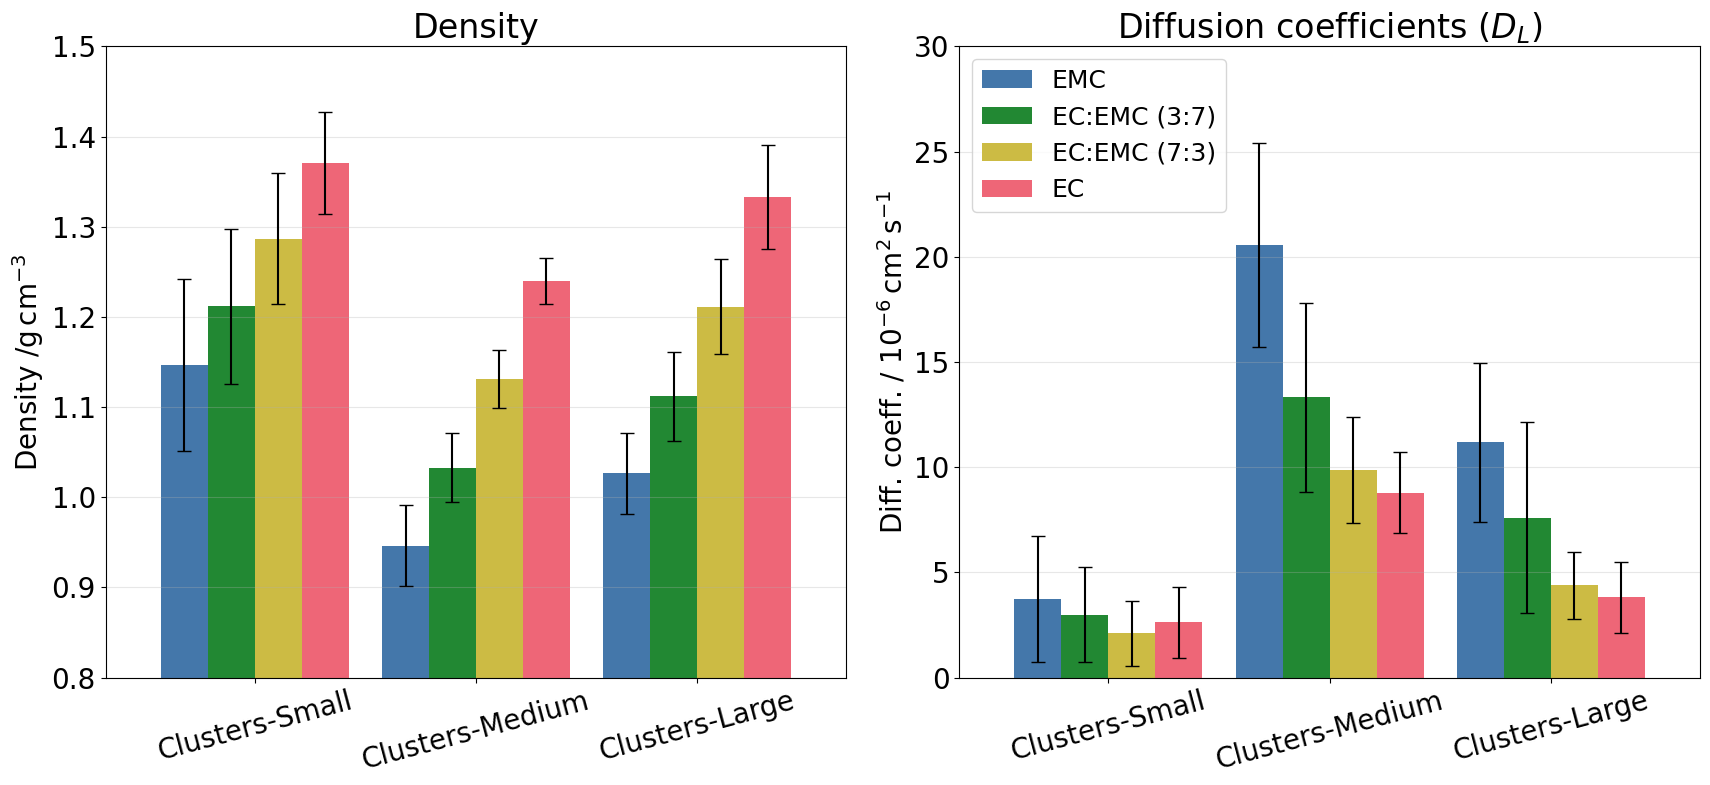

In [11]:
order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
group_order = [
    'Clusters-Small',
    'Clusters-Medium',
    'Clusters-Large',
]

plot_df = committee_df[committee_df['Labels'] == 'wB97X-D3']


# Pivot tables for plotting
dens_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Density /g*cm-3',
).reindex(group_order)[order]
dens_err_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Density std. /g*cm-3',
).reindex(group_order)[order]

diff_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Diff. coeff. /1e6 cm2*s-1',
).reindex(group_order)[order]
diff_err_df = plot_df.pivot(
	index='Data set',
	columns='Composition',
	values='Diff. fit slope error /1e6 cm2*s-1',
).reindex(group_order)[order]

fig, axs = plt.subplots(1,2, figsize=(7*scale, 3.3*scale), sharex=True, sharey=False)

a0 = dens_df.plot.bar(
    title='Density',
    ylim=[0.8,1.5],
    ylabel=f'Density /g$\\,$cm$^{{-3}}$',
    xlabel='',
    yerr=dens_err_df,
    capsize=5,
    rot=15,
    width=0.85,
    color=[funcs.get_colour(o) for o in order],
    ax=axs[0],
    legend=False,
)
axs[0].grid(axis='y', alpha=0.3)


a1 = diff_df.plot.bar(
    title='Diffusion coefficients ($D_L$)',
    ylim=[0,30],
    ylabel=f'Diff. coeff. / $10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
    xlabel='',
    yerr=diff_err_df,
    capsize=5,
    rot=15,
    width=0.85,
    color=[funcs.get_colour(o) for o in order],
    ax=axs[1],
    legend=False,
)
axs[1].grid(axis='y', alpha=0.3)
axs[1].legend(loc='upper left', fontsize=fsize-2)

plt.tight_layout()
#plt.savefig('../publication/plots/part2_committee_results.pdf', format='pdf', dpi=1200)

## Finite size correction of diffusion coefficients
For the diffusion data, we first need to compute the correction coefficients used by [Schrodinger SI, equ 5](https://pubs.acs.org/doi/suppl/10.1021/acs.jpcb.2c03746/suppl_file/jp2c03746_si_001.pdf) and [Bamboo, equ 61](https://arxiv.org/pdf/2404.07181), quoting [standard practice, equ 3](https://livecomsjournal.org/index.php/livecoms/article/view/v1i1e6324/937).
$$
D(\infty)=D(L)+\frac{2.837298\times k_BT}{6\pi \eta L}
$$
Box sizes are computed from number of molecules (table S1) and densities (table S2) from Schrodinger, temperatures are taken from table S1 and viscosity from table S3.

In [12]:
mass_thermo = funcs.get_all_thermo(f'{path}{tags[-1]}/dynamics/*', handle='.xyz')

for comp, traj in mass_thermo.items():
    if '000conEC' in comp:
        print('Pure EMC:')
        M_EMC = traj[0].get_masses().sum() # u=g/mol
        m_EMC = M_EMC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EMC} kg')
    elif '100conEC' in comp:
        print('Pure EC:')
        M_EC = traj[0].get_masses().sum() # u=g/mol
        m_EC = M_EC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EC} kg')

./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_000conEC_298K.xyz


./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_066conEC_298K.xyz


./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_033conEC_298K.xyz


./data/Clusters-Large/wB97XD3/SEED3/DSET1/dynamics/npt_100conEC_313K.xyz


Pure EMC:
Total mass:	1.1582317925845882e-23 kg
Pure EC:
Total mass:	1.462303889780969e-23 kg


In [13]:
m_EC = 1.462303889780969e-23 # kg
eta_EC = 1.93e-3 # Pa s
m_EMC = 1.1582317925845882e-23 # kg
eta_EMC = 0.65e-3 # Pa s*
kB = ase.units.kB/ase.units.J
xi = 2.837298
print(f'EMC viscosity:\t{eta_EMC} Pa s (at 298 K)')
print(f'EC viscosity:\t{eta_EC} Pa s (at 313 K)')
print(f'kB:\t\t{kB} J\n')

corr_df = committee_df.copy()
corr_df = corr_df[(corr_df['Composition'] == 'EMC') | (corr_df['Composition'] == 'EC')]
for tag, data in thermo.items():
    data_set, labels, seed, dset = tag.split('/')
    if (seed == 'SEED1') and (dset == 'DSET1'):
        print(tag)

    for comp, traj in data.items():
        temp = int(comp.split('_')[-1][:-1])
        time, msd, dens = funcs.get_dynamic_data(traj, handle=data_set)
        dens = np.mean(dens)*1000 # kg/m3

        if ('000conEC' in comp) and (seed == 'SEED1') and (dset == 'DSET1'):
            print('EMC:')
            total_mass = m_EMC
            eta = eta_EMC
            volume = total_mass/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        elif ('100conEC' in comp) and (seed == 'SEED1') and (dset == 'DSET1'):
            print('EC:')
            total_mass = m_EC
            eta = eta_EC
            volume = total_mass/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        else:
            corr = 0
        
        corr *= 1e10 # 1e-6 cm2/s
        if corr > 0:
            print(f'Box length:\t{L*1e10:.3f} Å')
            print(f'Correction:\t{corr:.3f} 1e-6cm2/s\n')

        data_mask = corr_df['Data set'] == data_set
        func_mask = corr_df['Labels'] == label_map[labels]
        comp_mask = corr_df['Composition'] == traj_map[comp]
        corr_df.loc[data_mask & func_mask & comp_mask, 'Diff. coeff. /1e6 cm2*s-1'] += corr
corr_df.round(decimals=2)

EMC viscosity:	0.00065 Pa s (at 298 K)
EC viscosity:	0.00193 Pa s (at 313 K)
kB:		1.38064852e-23 J

Clusters-Small/wB97XD3/SEED1/DSET1
EMC:
Box length:	21.699 Å
Correction:	4.391 1e-6cm2/s

EC:
Box length:	21.969 Å
Correction:	1.534 1e-6cm2/s

Clusters-Small/B97D3/SEED1/DSET1
EMC:
Box length:	21.936 Å
Correction:	4.343 1e-6cm2/s

EC:
Box length:	22.773 Å
Correction:	1.480 1e-6cm2/s

Clusters-Medium/wB97XD3/SEED1/DSET1
EMC:
Box length:	23.157 Å
Correction:	4.114 1e-6cm2/s

EC:
Box length:	22.806 Å
Correction:	1.478 1e-6cm2/s

Clusters-Medium/B97D3/SEED1/DSET1
EMC:
Box length:	22.325 Å
Correction:	4.268 1e-6cm2/s

EC:
Box length:	22.520 Å
Correction:	1.497 1e-6cm2/s

Clusters-Large/wB97XD3/SEED1/DSET1
EMC:
Box length:	22.104 Å
Correction:	4.310 1e-6cm2/s

EC:
Box length:	21.872 Å
Correction:	1.541 1e-6cm2/s



,Data set,Labels,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1
0,Clusters-Medium,B97-D3,EC,313,1.17,0.09,13.60,6.93
3,Clusters-Medium,B97-D3,EMC,298,0.90,0.12,29.07,14.63
4,Clusters-Small,B97-D3,EC,313,1.19,0.04,10.61,2.99
7,Clusters-Small,B97-D3,EMC,298,1.02,0.07,13.92,6.47
8,Clusters-Large,wB97X-D3,EC,313,1.33,0.06,5.35,1.67
11,Clusters-Large,wB97X-D3,EMC,298,1.03,0.05,15.49,3.79
12,Clusters-Medium,wB97X-D3,EC,313,1.24,0.03,10.27,1.90
15,Clusters-Medium,wB97X-D3,EMC,298,0.95,0.04,24.69,4.85
16,Clusters-Small,wB97X-D3,EC,313,1.37,0.06,4.16,1.69
19,Clusters-Small,wB97X-D3,EMC,298,1.15,0.09,8.12,2.98


___
# SI

## Density and diffusion
### Effects random seed and sampling

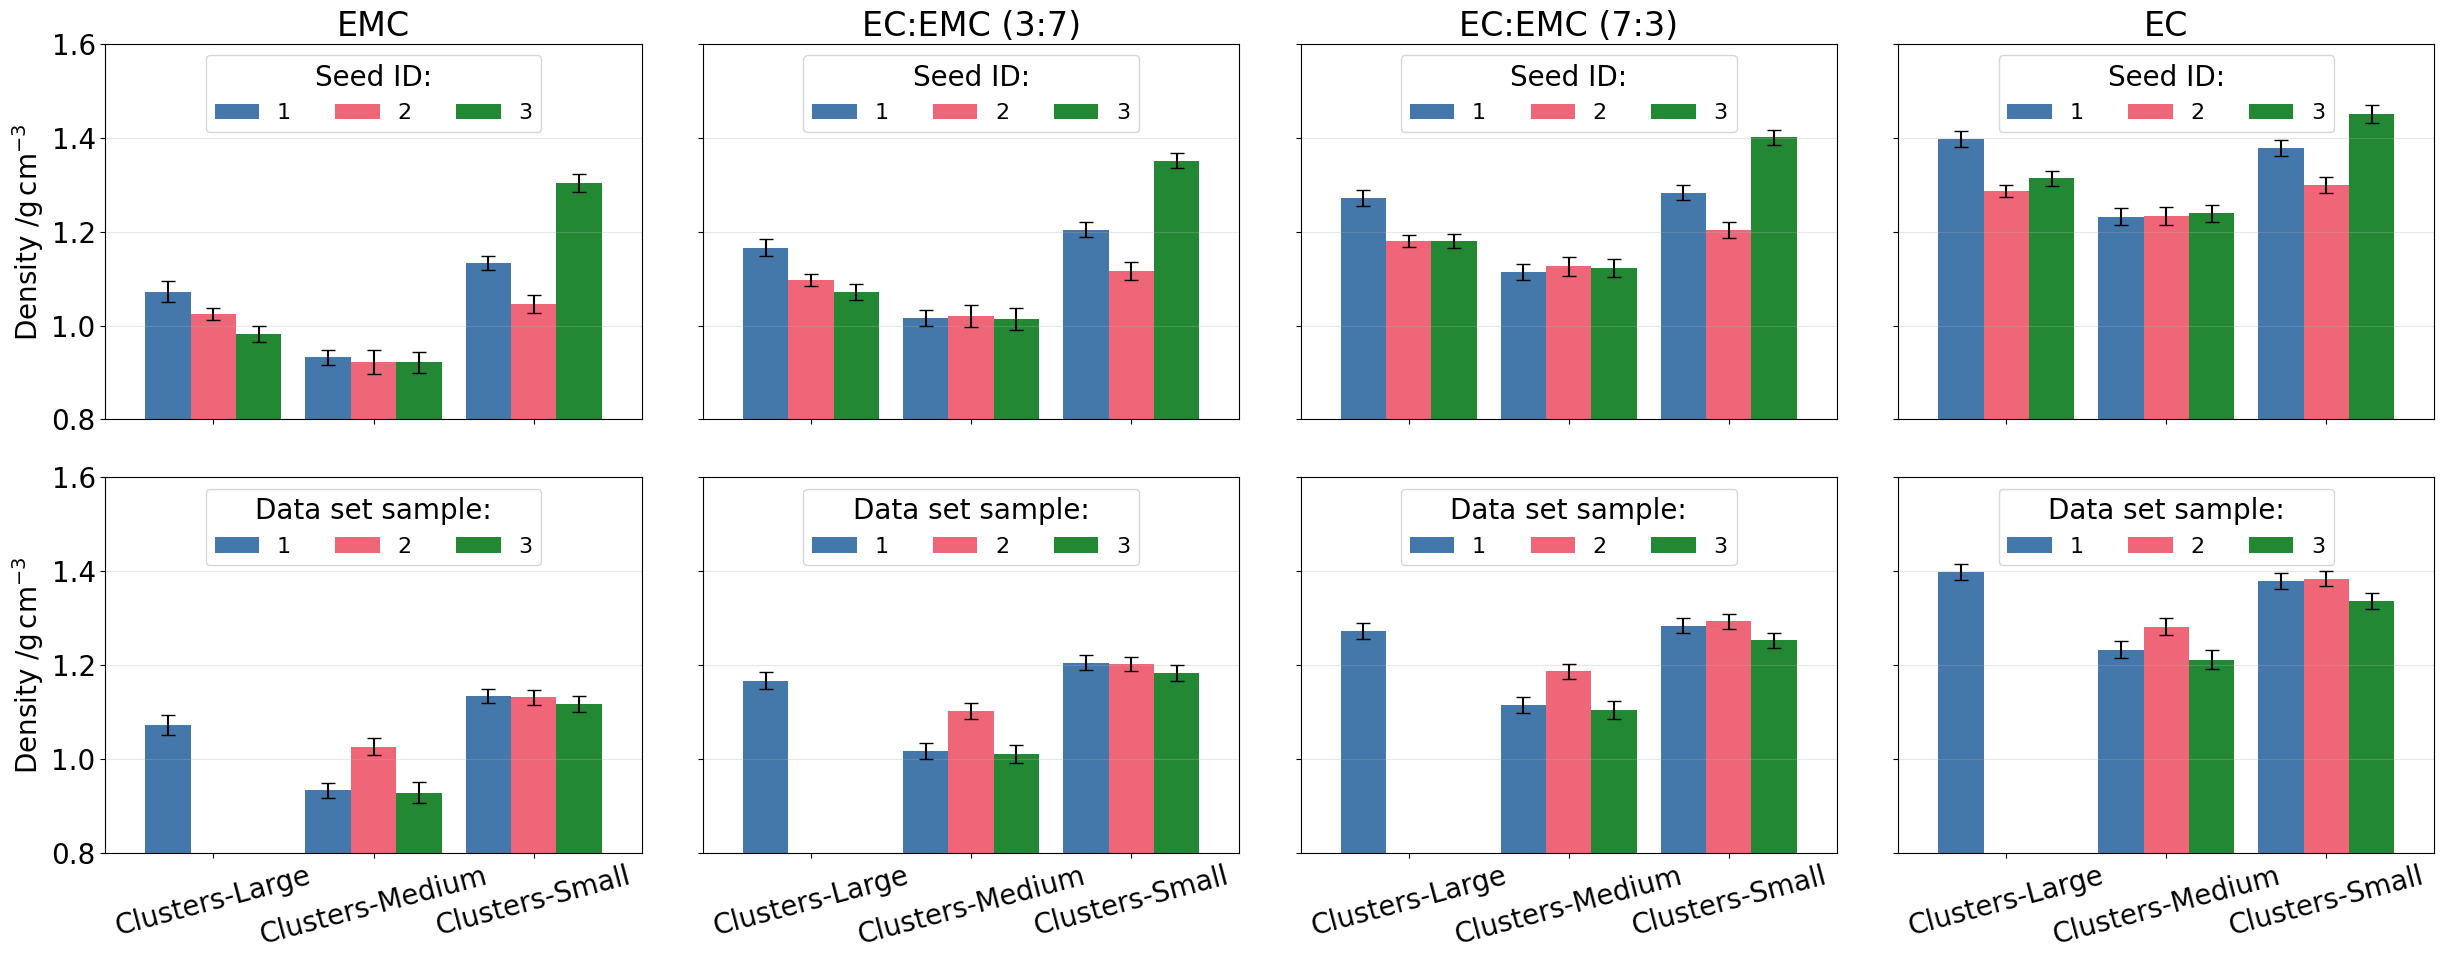

In [14]:
order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
wB97X_df = df.copy()[df['Labels'] == 'wB97X-D3']
wB97X_df['Composition'] = pd.Categorical(wB97X_df['Composition'], categories=order, ordered=True)
wB97X_df = wB97X_df.sort_values('Composition')


fig, axs = plt.subplots(2,4, figsize=(10*scale, 4*scale), sharey='row', sharex='col')

seed_df = wB97X_df[wB97X_df['Sample ID'] == 1]
for ax, (n,g) in zip(axs[0,:], seed_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Density std. /g*cm-3',
    )
    a0 = avg_g.plot.bar(
        title=n,
        ylim=[0.8,1.6],
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Seed ID:', ncols=3, loc='upper center', fontsize=fsize-4)


sample_df = wB97X_df[wB97X_df['Seed ID'] == 1]
for ax, (n,g) in zip(axs[1,:], sample_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Density std. /g*cm-3',
    )
    a1 = avg_g.plot.bar(
        ylim=[0.8,1.6],
        xlabel='',
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Data set sample:', ncols=3, loc='upper center', fontsize=fsize-4)

plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_densities.pdf', format='pdf', dpi=1200)

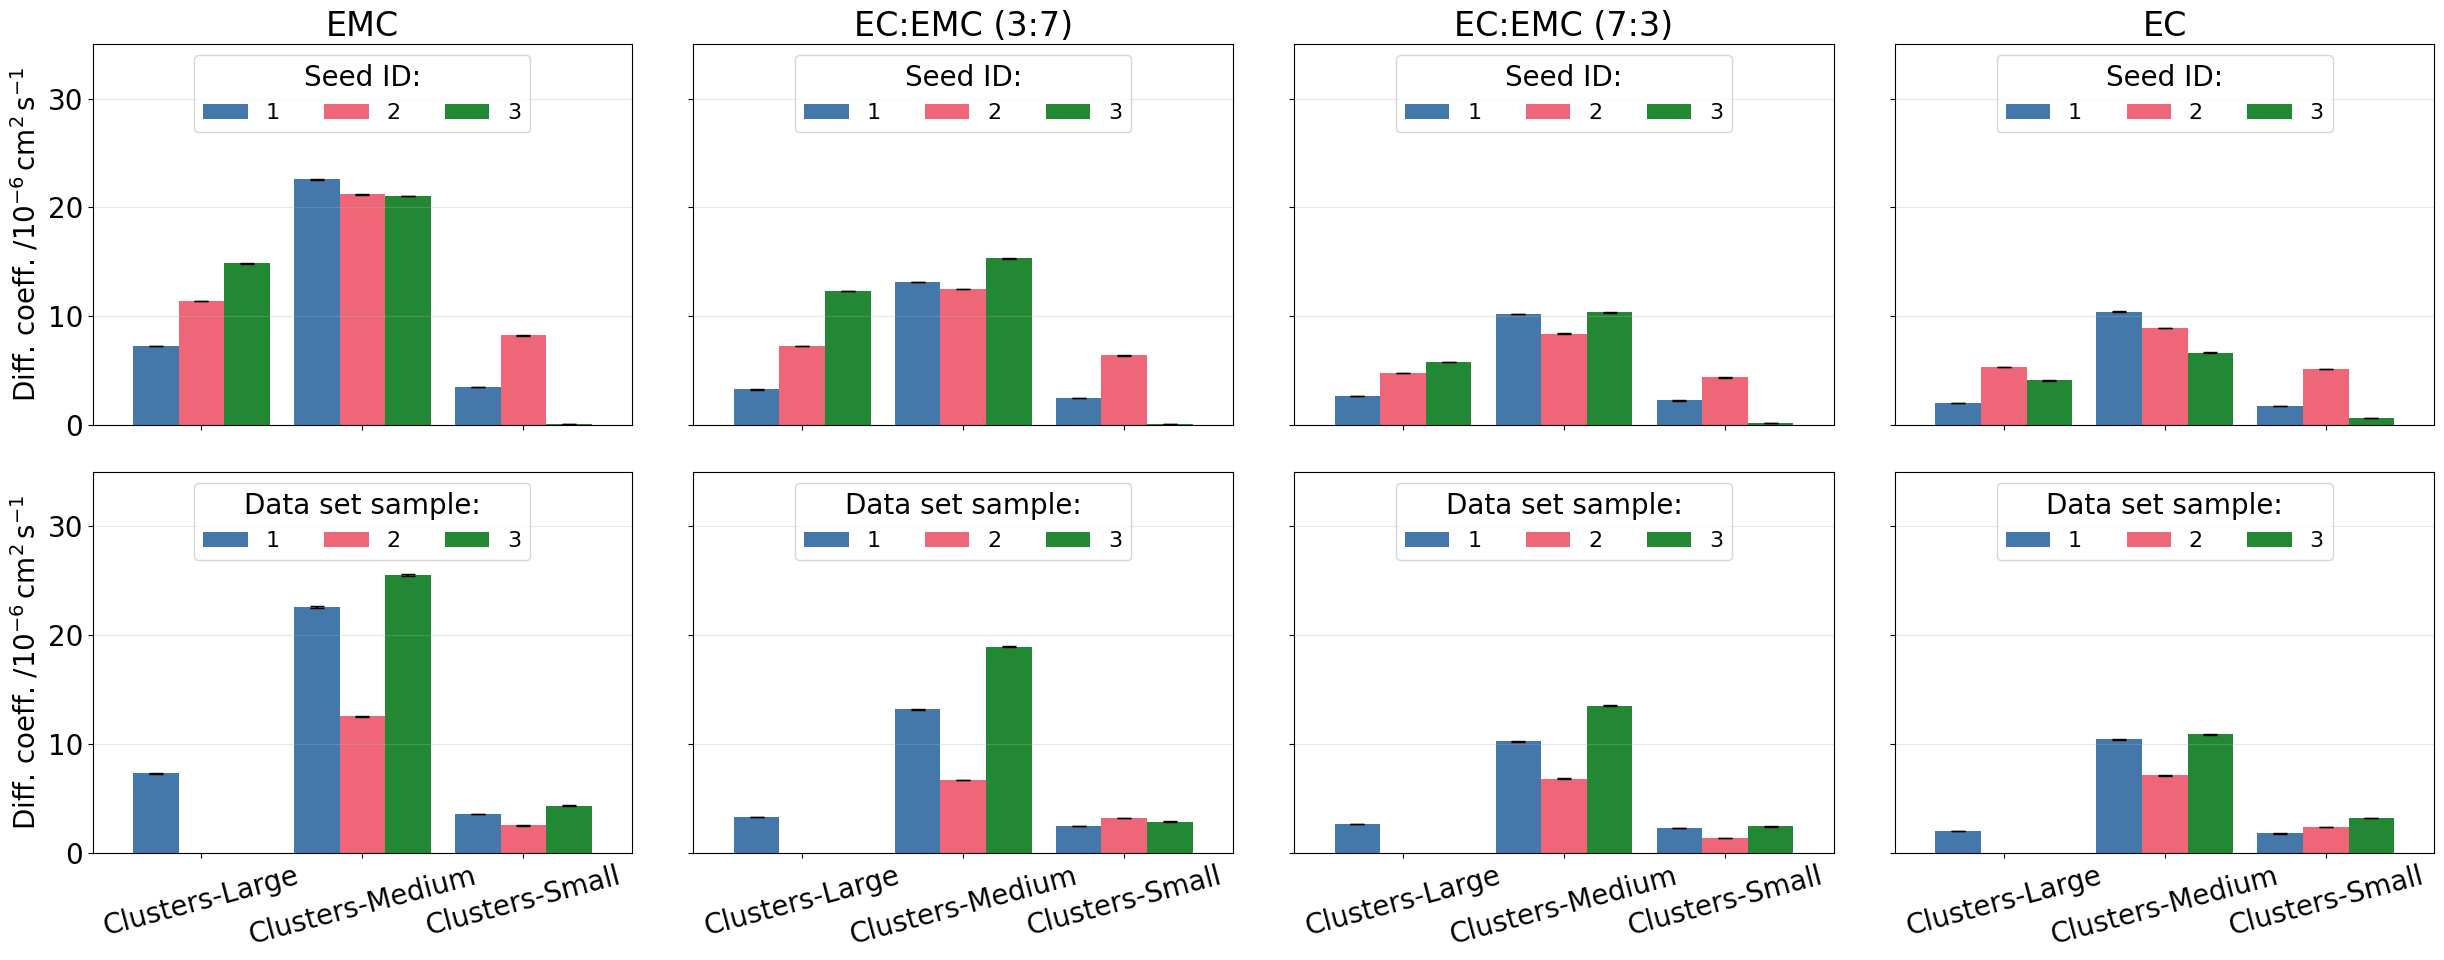

In [15]:
order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
wB97X_df = df.copy()[df['Labels'] == 'wB97X-D3']
wB97X_df['Composition'] = pd.Categorical(wB97X_df['Composition'], categories=order, ordered=True)
wB97X_df = wB97X_df.sort_values('Composition')


fig, axs = plt.subplots(2,4, figsize=(10*scale, 4*scale), sharey='row', sharex='col')

seed_df = wB97X_df[wB97X_df['Sample ID'] == 1]
for ax, (n,g) in zip(axs[0,:], seed_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Seed ID',
        values='Density std. /g*cm-3',
    )
    a0 = avg_g.plot.bar(
        title=n,
        ylim=[0,35],
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Seed ID:', ncols=3, loc='upper center', fontsize=fsize-4)


sample_df = wB97X_df[wB97X_df['Seed ID'] == 1]
for ax, (n,g) in zip(axs[1,:], sample_df.groupby('Composition',observed=False)):
    avg_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Data set',
        columns='Sample ID',
        values='Diff. fit slope error /1e6 cm2*s-1',
    )
    a1 = avg_g.plot.bar(
        ylim=[0,35],
        xlabel='',
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        rot=15,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Data set sample:', ncols=3, loc='upper center', fontsize=fsize-4)

plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_diffusivities.pdf', format='pdf', dpi=1200)

### Effect of change of DFT functional

In [16]:
B97_df = df.copy()[df['Labels'] == 'B97-D3']
wB97X_seed1_df = wB97X_df.copy()[wB97X_df['Seed ID'] == 1]
B97_v_wB97X = pd.concat([B97_df, wB97X_seed1_df])

Clusters-Small:

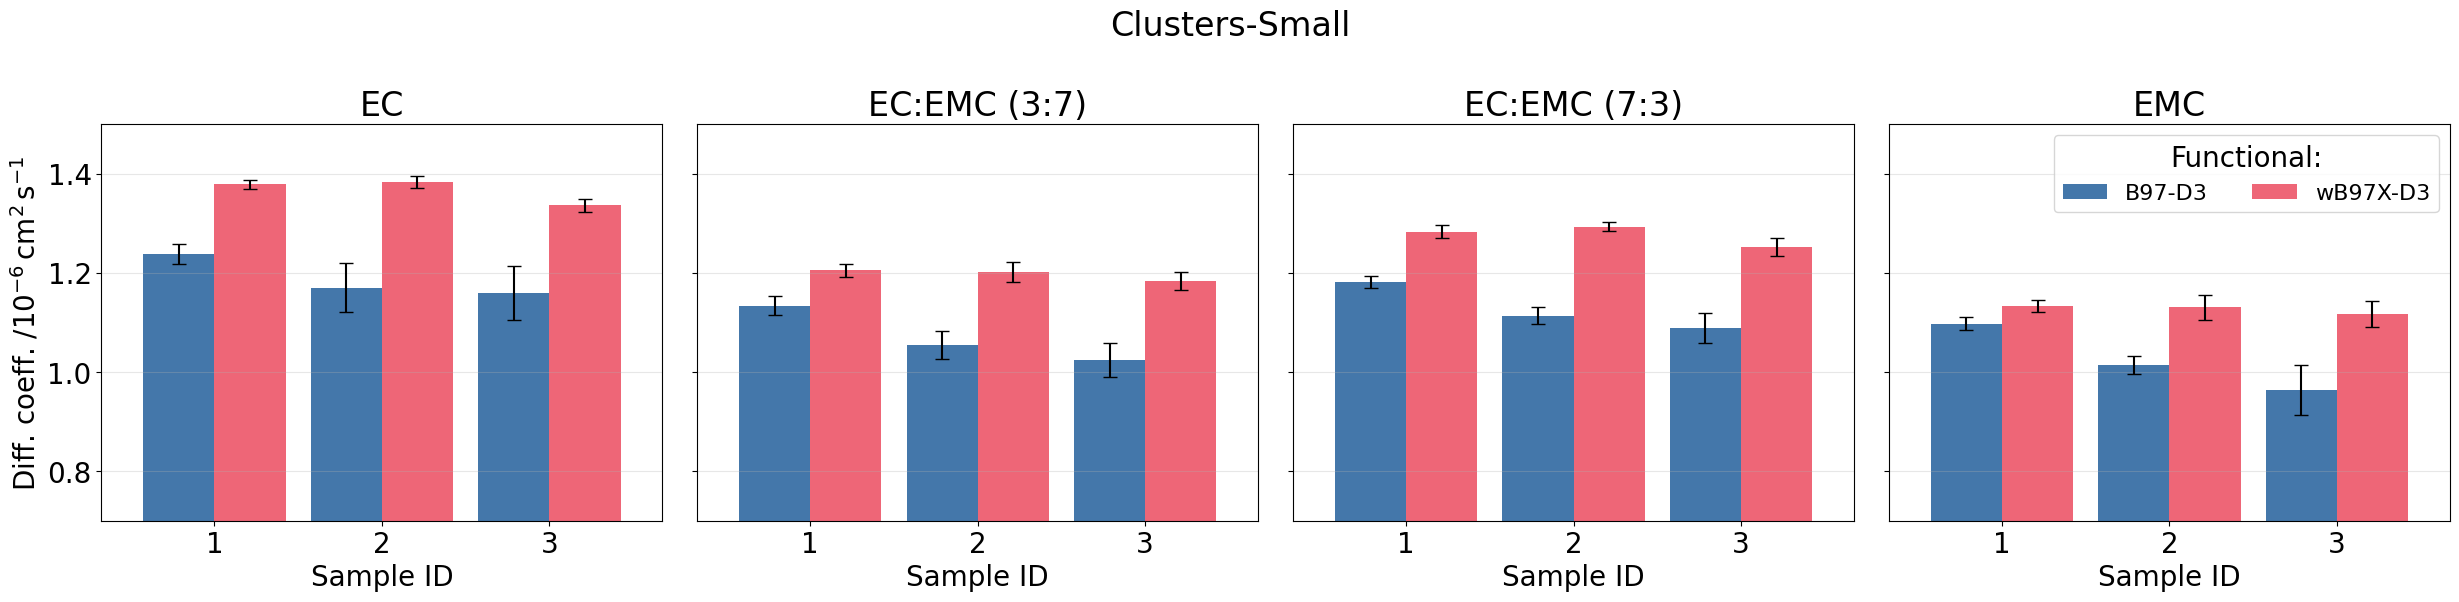

In [17]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)

B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Small'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Small')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. fit slope error /1e6 cm2*s-1',
    )
    a1 = avg_g.plot.bar(
        ylim=[0.7,1.5],
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[-1].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_density_func-comp_small.pdf', format='pdf', dpi=1200)

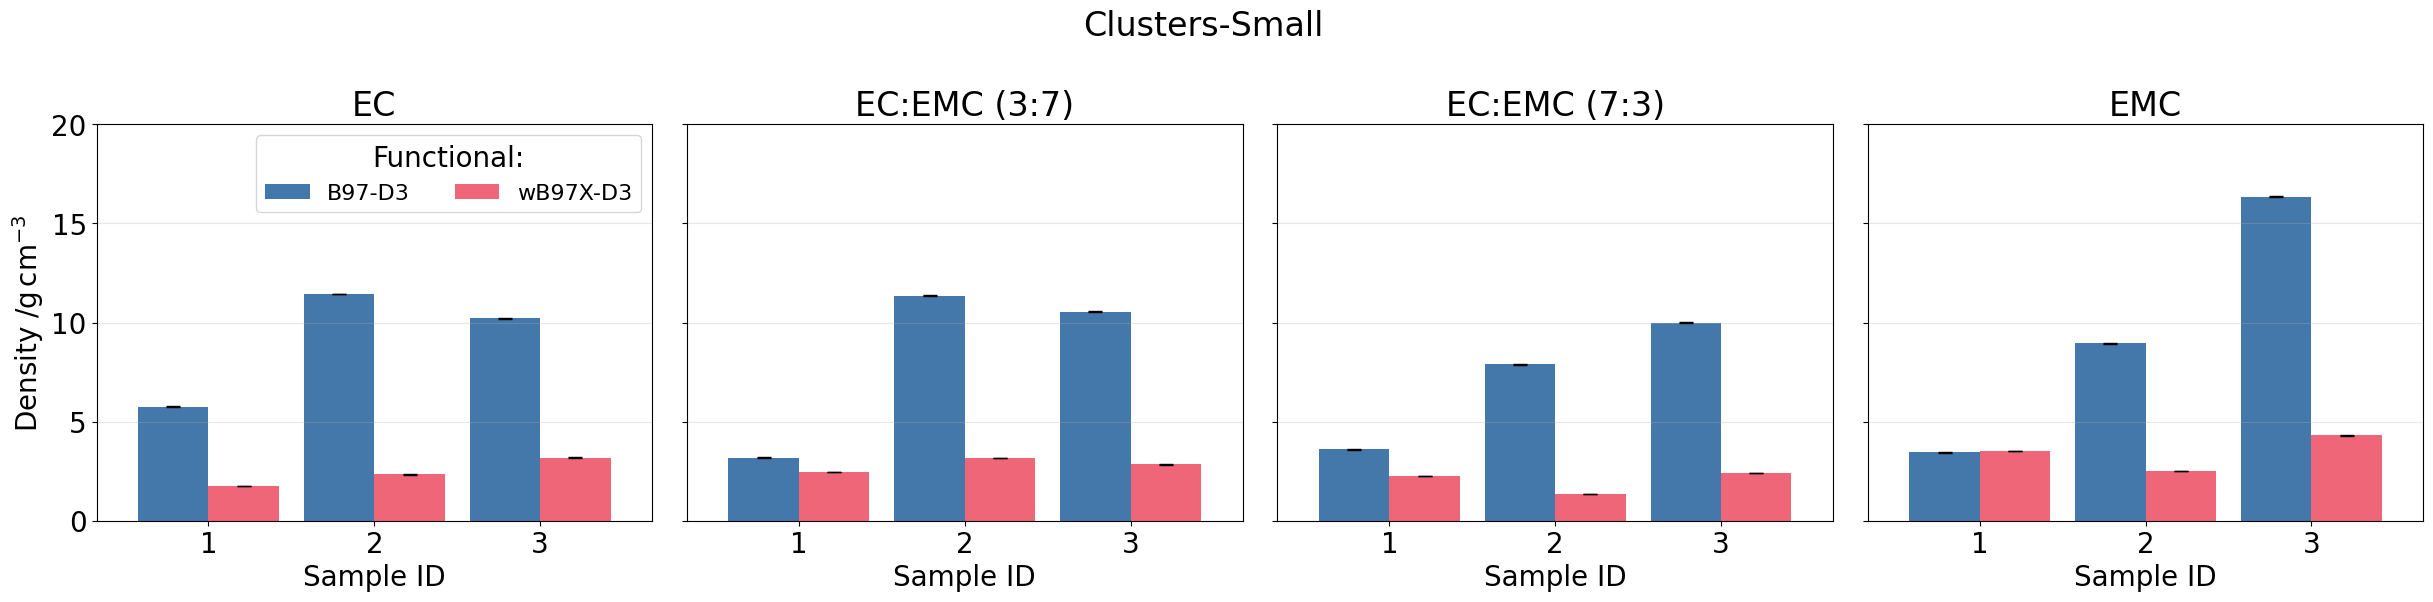

In [18]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)

B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Small'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Small')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density std. /g*cm-3',
    )
    a1 = avg_g.plot.bar(
        ylim=[0,20],
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[0].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_diffusivity_func-comp_small.pdf', format='pdf', dpi=1200)

Clusters-Medium:

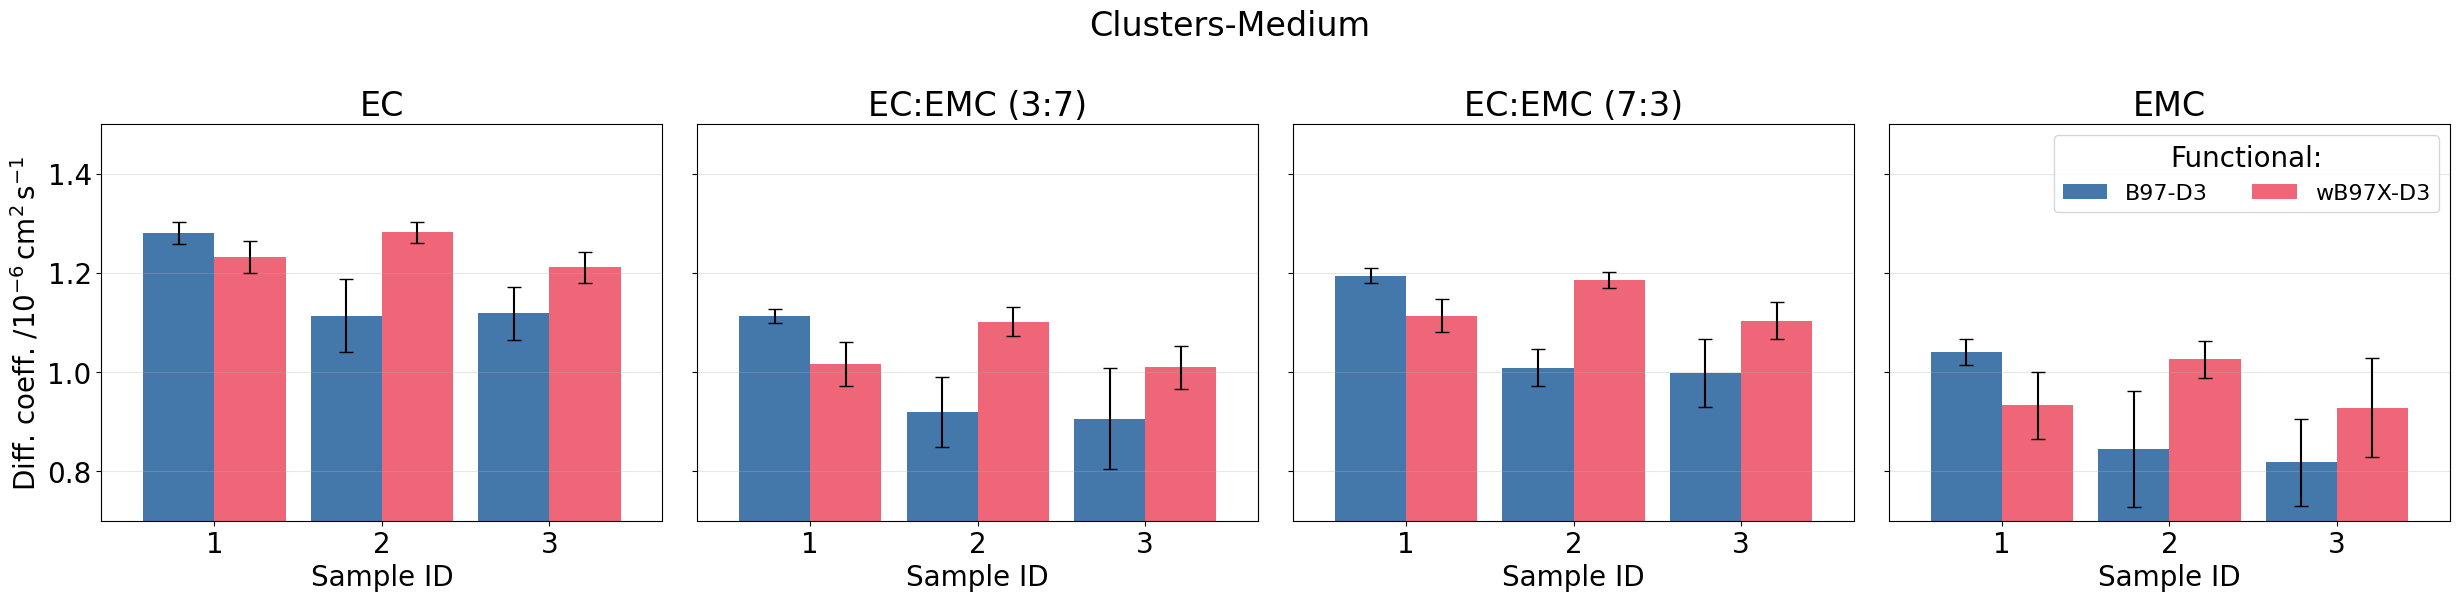

In [19]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)

B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Medium'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Medium')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density /g*cm-3',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. fit slope error /1e6 cm2*s-1',
    )
    a1 = avg_g.plot.bar(
        ylim=[0.7,1.5],
        ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[-1].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_density_func-comp_medium.pdf', format='pdf', dpi=1200)

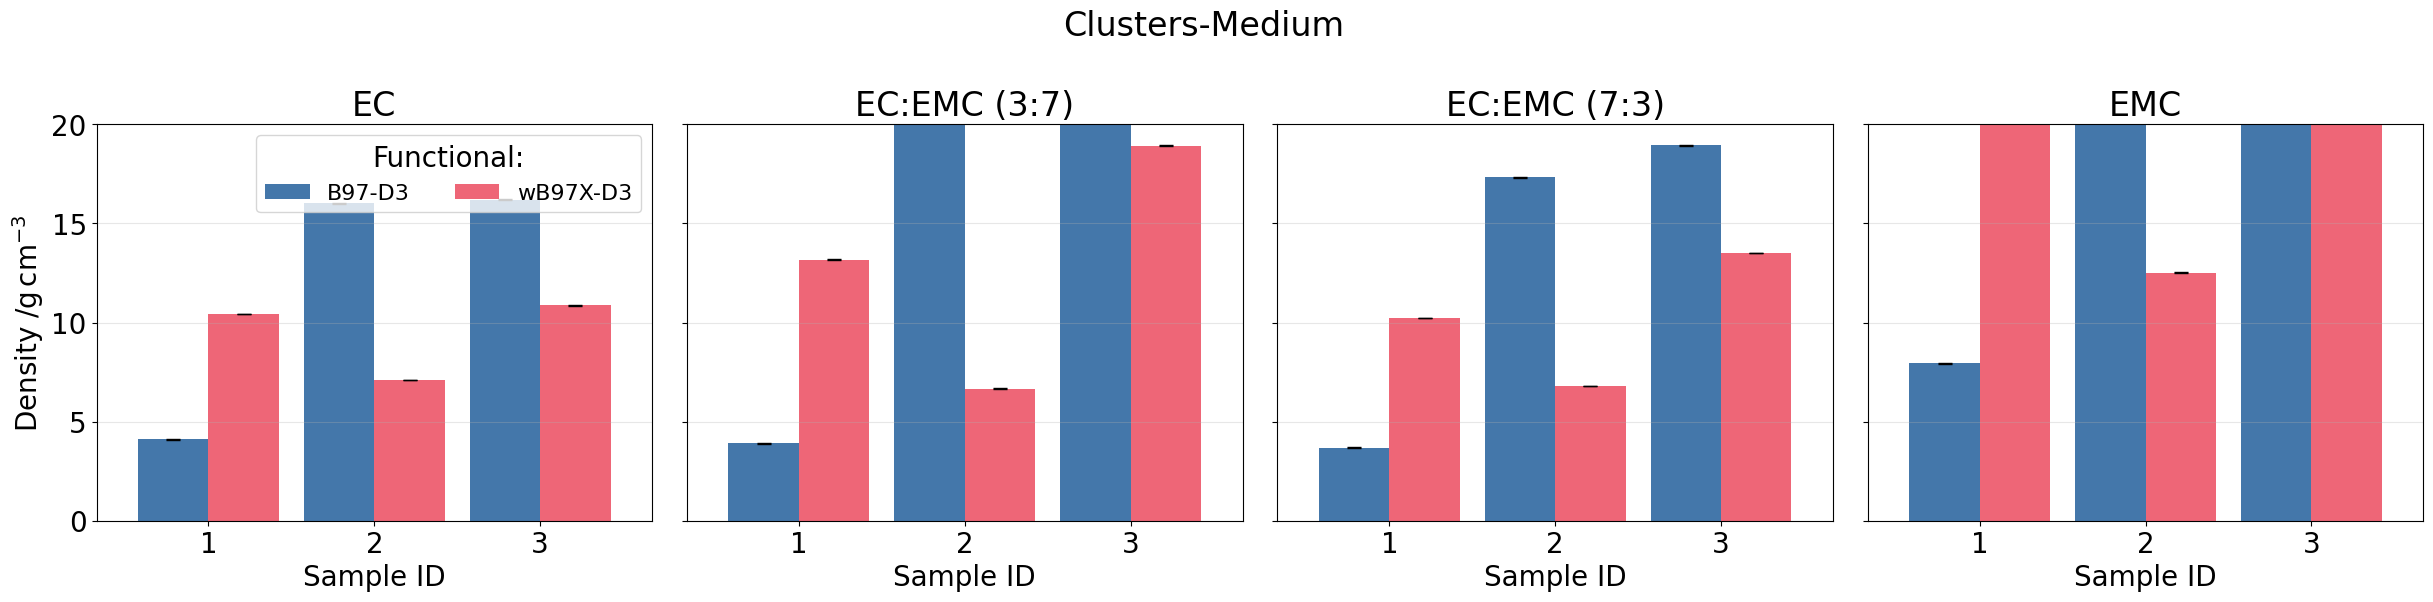

In [20]:
fig, axs = plt.subplots(1,4, figsize=(10*scale, 2.5*scale), sharey=True)

B97_v_wB97X_small = B97_v_wB97X[B97_v_wB97X['Data set'] == 'Clusters-Medium'].drop('Seed ID', axis=1)

fig.suptitle('Clusters-Medium')
for ax, (n,g) in zip(axs, B97_v_wB97X_small.groupby('Composition', observed=False)):
    ax.set_title(n)
    avg_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Diff. coeff. /1e6 cm2*s-1',
    )
    std_g = g.pivot(
        index='Sample ID',
        columns='Labels',
        values='Density std. /g*cm-3',
    )
    a1 = avg_g.plot.bar(
        ylim=[0,20],
        ylabel=f'Density /g$\\,$cm$^{{-3}}$',
        yerr=std_g,
        capsize=5,
        color=cset,
        rot=0,
        width=0.85,
        legend=False,
        ax=ax,
    )
    ax.grid(axis='y', alpha=0.3)

axs[0].legend(title='Functional:', ncols=3, loc='upper right', fontsize=fsize-4)
plt.tight_layout()

#plt.savefig('../publication/plots/SI/part2_diffusivity_func-comp_medium.pdf', format='pdf', dpi=1200)

## Structural comparison between periodic- and cluster-based training sets

In [21]:
cluster_inter_pkl = './cluster_inter_rdfs.pkl'
MD_inter_pkl = './MD_inter_rdfs.pkl'
rmax = 10
nbins = 100
cluster_rdfs = {}
cluster_nbrs = {}

Read MD trajectories:

Compute average neighbour distributions/RDFs across liquid compositions and save as pickle:

>NOTE: This ecell below requires that the files related to the periodic models (`part1-dft_impact-periodic_data.ipynb`) has been downloaded.

In [22]:
try:
    # Load cached MD reference data
    with open(MD_inter_pkl, 'rb') as f:
        reference_coordination =  pickle.load(f)
        f.close()
    g_ref_inter, r_ref_inter, rho_ref_inter = reference_coordination['RDF']
    n_ref_inter, r_ref_inter = reference_coordination['Nbrs'] 
except:
    ref_trajs = funcs.get_all_thermo(path+'Periodic/PBED3/SEED1/DSET1/dynamics/*', handle='.xyz')

    from functools import partial
    func = partial(funcs.evaluate_nbr_distributions, rmax=rmax, inter_only=True, use_max=False, pbc=True)
    result_dict = dict(funcs.parallelize_eval(func, ref_trajs.items()))

    reference_coordination = {'RDF':{},'Nbrs':{}}
    g_ref_inter, n_ref_inter, rho_ref_inter = 0,0,0
    for i, (label, data) in enumerate(result_dict.items()):
        g_prime, n_prime, r_ref_inter, rho_prime = data
        g_ref_inter += g_prime/(i+1)
        n_ref_inter += n_prime/(i+1)
        rho_ref_inter += rho_prime/(i+1)
    reference_coordination['RDF'] = (g_ref_inter, r_ref_inter, rho_ref_inter)
    reference_coordination['Nbrs'] = (n_ref_inter, r_ref_inter)

    with open(MD_inter_pkl, 'wb') as f:
        pickle.dump(reference_coordination, f)
        f.close()

Read xyz data and filter according to cluster sizes. Note that for the small and medium datasets, only the first dataset is selected here. Since Clusters-Large contains all clusters there are none left out in this analysis.

In [23]:
try:
    # Load cached cluster data
    with open(cluster_inter_pkl, 'rb') as f:
        coordinations = pickle.load(f)
        f.close()
    cluster_rdfs = coordinations['RDF']
    cluster_nbrs = coordinations['Nbrs']
except:
    import pickle

    print('Reading Clusters-Small...')
    with open(small_pkl, 'rb') as f:
        clusters_small_dict = pickle.load(f)
    clusters_small_xyz = [a for a in clusters_small_dict['Clusters-Small-1'] if a.info['Nmols'] > 1]
    print('Reading Clusters-Medium...')
    with open(medium_pkl, 'rb') as f:
        clusters_medium_dict = pickle.load(f)
    clusters_medium_xyz = [a for a in clusters_medium_dict['Clusters-Medium-1'] if a.info['Nmols'] > 1]
    print('Reading Clusters-Large...')
    with open(large_pkl, 'rb') as f:
        clusters_large_dict = pickle.load(f)
    clusters_large_xyz = [a for a in clusters_large_dict['Clusters-Large'] if a.info['Nmols'] > 1]
    print('Done!')

    print('Neighbour distributions:')
    print('Clusters-Large')
    cluster_nbrs['Clusters-Large'] = funcs.compute_rdf(clusters_large_xyz, rmax=rmax, nbins=nbins, use_max=False, inter_only=True, nbr_density=True, return_rho=False, pbc=False)
    print('Clusters-Medium')
    cluster_nbrs['Clusters-Medium'] = funcs.compute_rdf(clusters_medium_xyz, rmax=rmax, nbins=nbins, use_max=False, inter_only=True, nbr_density=True, return_rho=False, pbc=False)
    print('Clusters-small')
    cluster_nbrs['Clusters-Small'] = funcs.compute_rdf(clusters_small_xyz, rmax=rmax, nbins=nbins, use_max=False, inter_only=True, nbr_density=True, return_rho=False, pbc=False)

    print('RDFs:')
    print('Clusters-Large, max')
    cluster_rdfs['Clusters-Large-max'] = funcs.compute_rdf(clusters_large_xyz, rmax=rmax, nbins=nbins, rho=rho_ref_inter, use_max=True, inter_only=True, nbr_density=False, return_rho=False, pbc=False)
    print('Clusters-Large, mean')
    cluster_rdfs['Clusters-Large-mean'] = funcs.compute_rdf(clusters_large_xyz, rmax=rmax, nbins=nbins, rho=rho_ref_inter, use_max=False, inter_only=True, nbr_density=False, return_rho=False, pbc=False)

    print('Done!')
    coordinations = {'RDF':cluster_rdfs, 'Nbrs':cluster_nbrs}
    with open(cluster_inter_pkl, 'wb') as f:
        pickle.dump(coordinations, f)
        f.close()

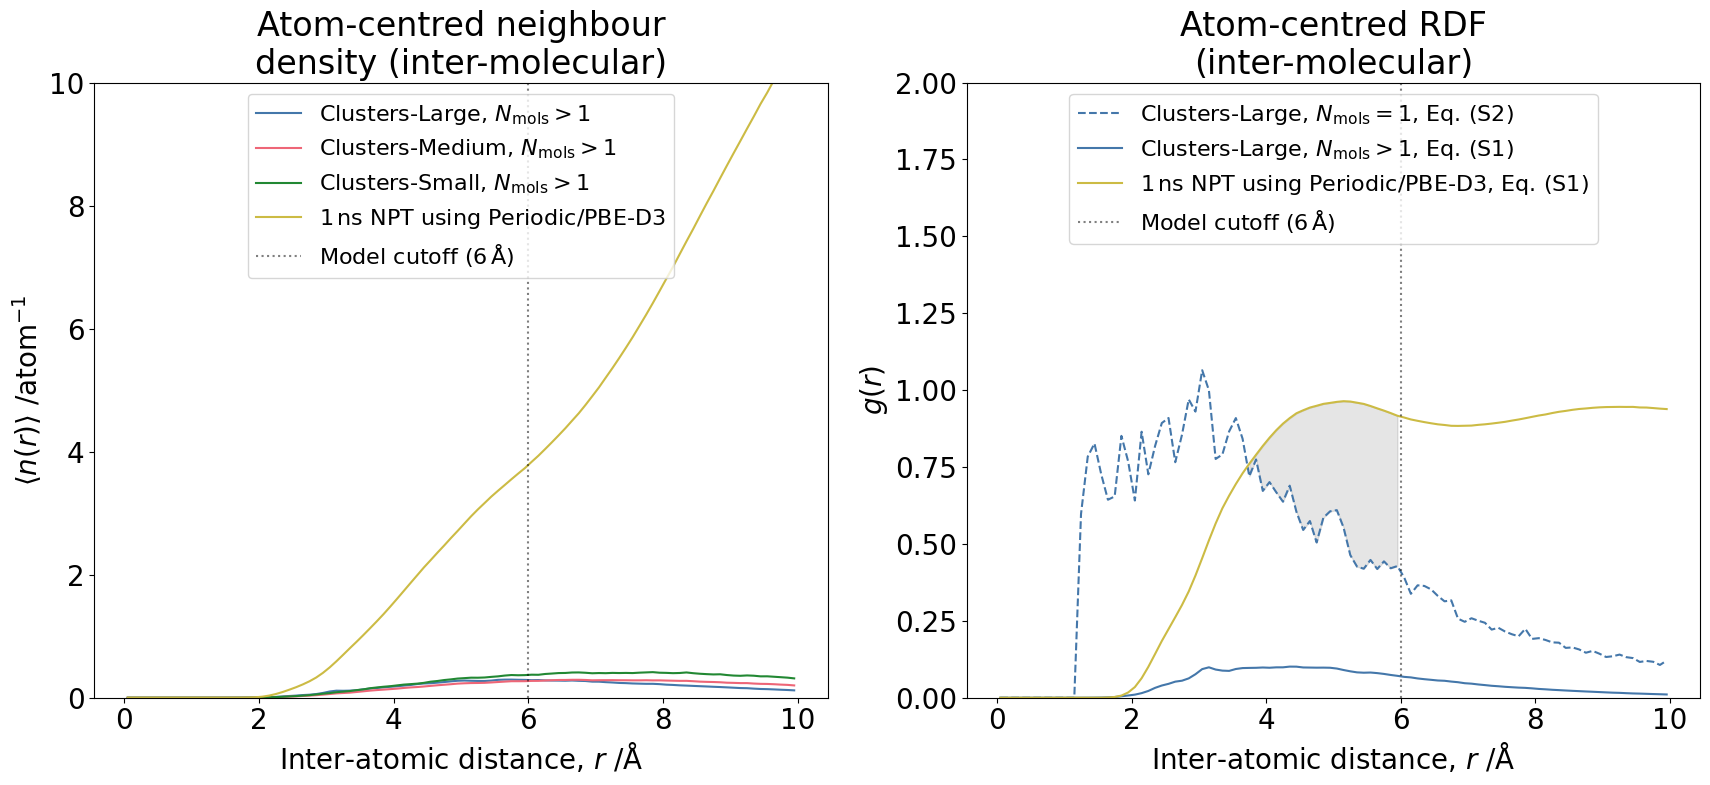

In [24]:
name_map = {
    'Clusters-Large-max':'Clusters-Large, $N_\\text{mols}=1$, Eq. (S2)',
    'Clusters-Large-mean':'Clusters-Large, $N_\\text{mols}>1$, Eq. (S1)',
    'Clusters-Large':'Clusters-Large, $N_\\text{mols}>1$',
    'Clusters-Medium':'Clusters-Medium, $N_\\text{mols}>1$',
    'Clusters-Small':'Clusters-Small, $N_\\text{mols}>1$',
}


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7*scale, 3.3*scale), sharey=False)

ax1.set_title('Atom-centred neighbour\ndensity (inter-molecular)')
ax1.set_ylim([None,10])
ax1.set_xlabel('Inter-atomic distance, $r$ /Å')
ax1.set_ylabel('$\\langle n(r) \\rangle$ /atom$^{-1}$')
for name, data in cluster_nbrs.items():
    n, r = data
    ax1.plot(r,n, '-', label=name_map[name])

ax1.plot(r_ref_inter,n_ref_inter, color=cset[3], label='1$\\,$ns NPT using Periodic/PBE-D3')
ax1.axvline(x=6.0, linestyle=':', color='black', alpha=0.5, label='Model cutoff (6$\\,$Å)')
ax1.legend(loc='upper center', fontsize=fsize-4)

ax2.set_title('Atom-centred RDF\n(inter-molecular)')
ax2.set_xlabel('Inter-atomic distance, $r$ /Å')
ax2.set_ylabel('$g(r)$')
ax2.set_ylim([None,2])
for name, data in cluster_rdfs.items():
    g, r = data    
    if 'mean' in name:
        g_mean = g
        ax2.plot(r,g_mean, '-', color=cset.blue, label=name_map[name])
    elif 'max' in name:
        g_max = g
        ax2.plot(r,g_max, '--', color=cset.blue, label=name_map[name])
    
ax2.fill_between(r[r<=6], g_max[r<=6], g_ref_inter[r<=6], g_max[r<=6]<g_ref_inter[r<=6], color='black', alpha=0.1)


ax2.plot(r_ref_inter,g_ref_inter, color=cset[3], label='1$\\,$ns NPT using Periodic/PBE-D3, Eq. (S1)')
ax2.axvline(x=6.0, linestyle=':', color='black', alpha=0.5, label='Model cutoff (6$\\,$Å)')
ax2.legend(loc='upper center', fontsize=fsize-4)

plt.tight_layout()
#plt.savefig('./part2_pair-coordination.pdf', format='pdf', dpi=1200)

## Structural properties of liquids

Compute RDFs and save as pickle:

In [25]:
try:
    with open('./part2_rdfs.pkl', 'rb') as f:
        rdfs = pickle.load(f)
    with open('./part2_rhos.pkl', 'rb') as f:
        number_densities = pickle.load(f)
except:
    wB97X_tags = [
        'Clusters-Small/wB97XD3/SEED1/DSET1',
        'Clusters-Small/wB97XD3/SEED1/DSET2',
        'Clusters-Small/wB97XD3/SEED1/DSET3',
        'Clusters-Small/wB97XD3/SEED2/DSET1',
        'Clusters-Small/wB97XD3/SEED3/DSET1',
        'Clusters-Medium/wB97XD3/SEED1/DSET1',
        'Clusters-Medium/wB97XD3/SEED1/DSET2',
        'Clusters-Medium/wB97XD3/SEED1/DSET3',
        'Clusters-Medium/wB97XD3/SEED2/DSET1',
        'Clusters-Medium/wB97XD3/SEED3/DSET1',
        'Clusters-Large/wB97XD3/SEED1/DSET1',
        'Clusters-Large/wB97XD3/SEED2/DSET1',
        'Clusters-Large/wB97XD3/SEED3/DSET1',
    ]
    
    rdfs, number_densities = funcs.get_mol_rdfs(path, wB97X_tags)
    
    with open('./part2_rdfs.pkl', 'wb') as f:
        pickle.dump(rdfs, f)
    with open('./part2_rhos.pkl', 'wb') as f:
        pickle.dump(number_densities, f)

Read RDFs from pickle:

In [26]:
rstart = 6
id_width = 20

radii = []
for model,dsets in rdfs.items():
    training_data = model.split('_')[0]
    for dset,seeds in dsets.items():
        for seed,comps in seeds.items():
            for comp, (g, r) in comps.items():
                if comp == 'EC': temp = 313
                else: temp = 298

                id0 = np.where(r>rstart)[0][0]                
                idhi = id0+id_width
                rmin = min(r[id0:idhi])
                idx = np.argmin(g[id0:idhi])
                
                rho = number_densities[model][dset][seed][comp]
                r_prime = r[:id0+idx]
                g_prime = g[1:id0+idx]                        
                v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                N = sum(g_prime*v_shell*rho)
                train_data, functional = model.split('_')
                
                radii.append([training_data, functional, int(seed[-1]), int(dset[-1]), comp, temp, r[id0+idx], N])

radii_df = pd.DataFrame(radii, columns=['Data set', 'Functional', 'Seed ID', 'Sample ID', 'Composition', 'Temperature', 'Rmin', 'CN'])
for name, group in radii_df.groupby('Data set'):
    print('Average first shell coordinations:')
    print(name, group['CN'].mean(), '\n')
radii_df

Average first shell coordinations:
Clusters-Large 9.754363556084144 

Average first shell coordinations:
Clusters-Medium 9.041401405391754 

Average first shell coordinations:
Clusters-Small 10.377932878633384 



,Data set,Functional,Seed ID,Sample ID,Composition,Temperature,Rmin,CN
0,Clusters-Small,wB97XD3,1,1,EMC,298,8.195,11.988117
1,Clusters-Small,wB97XD3,1,1,EC:EMC (7:3),298,7.205,9.833874
2,Clusters-Small,wB97XD3,1,1,EC:EMC (3:7),298,7.975,12.307413
3,Clusters-Small,wB97XD3,1,1,EC,313,6.985,10.512331
4,Clusters-Small,wB97XD3,2,1,EMC,298,8.195,10.927079
5,Clusters-Small,wB97XD3,2,1,EC:EMC (7:3),298,7.315,9.576814
6,Clusters-Small,wB97XD3,2,1,EC:EMC (3:7),298,7.645,9.689100
7,Clusters-Small,wB97XD3,2,1,EC,313,7.205,10.708805
8,Clusters-Small,wB97XD3,3,1,EMC,298,8.085,13.425760
9,Clusters-Small,wB97XD3,3,1,EC:EMC (7:3),298,7.205,10.742233


In [27]:
cn_df = radii_df.copy().drop('Functional', axis=1)

seed_cn_df = cn_df.copy()
seed_cn_agg_df = seed_cn_df.groupby(['Data set', 'Composition', 'Sample ID'], as_index=False).agg(
    mean_value=('CN', 'mean'),
    std_value=('CN', 'std')
).dropna().drop('Sample ID', axis=1)

sample_cn_df = cn_df.copy()
sample_cn_agg_df = sample_cn_df.groupby(['Data set', 'Composition', 'Seed ID'], as_index=False).agg(
    mean_value=('CN', 'mean'),
    std_value=('CN', 'std')
).dropna().drop('Seed ID', axis=1)

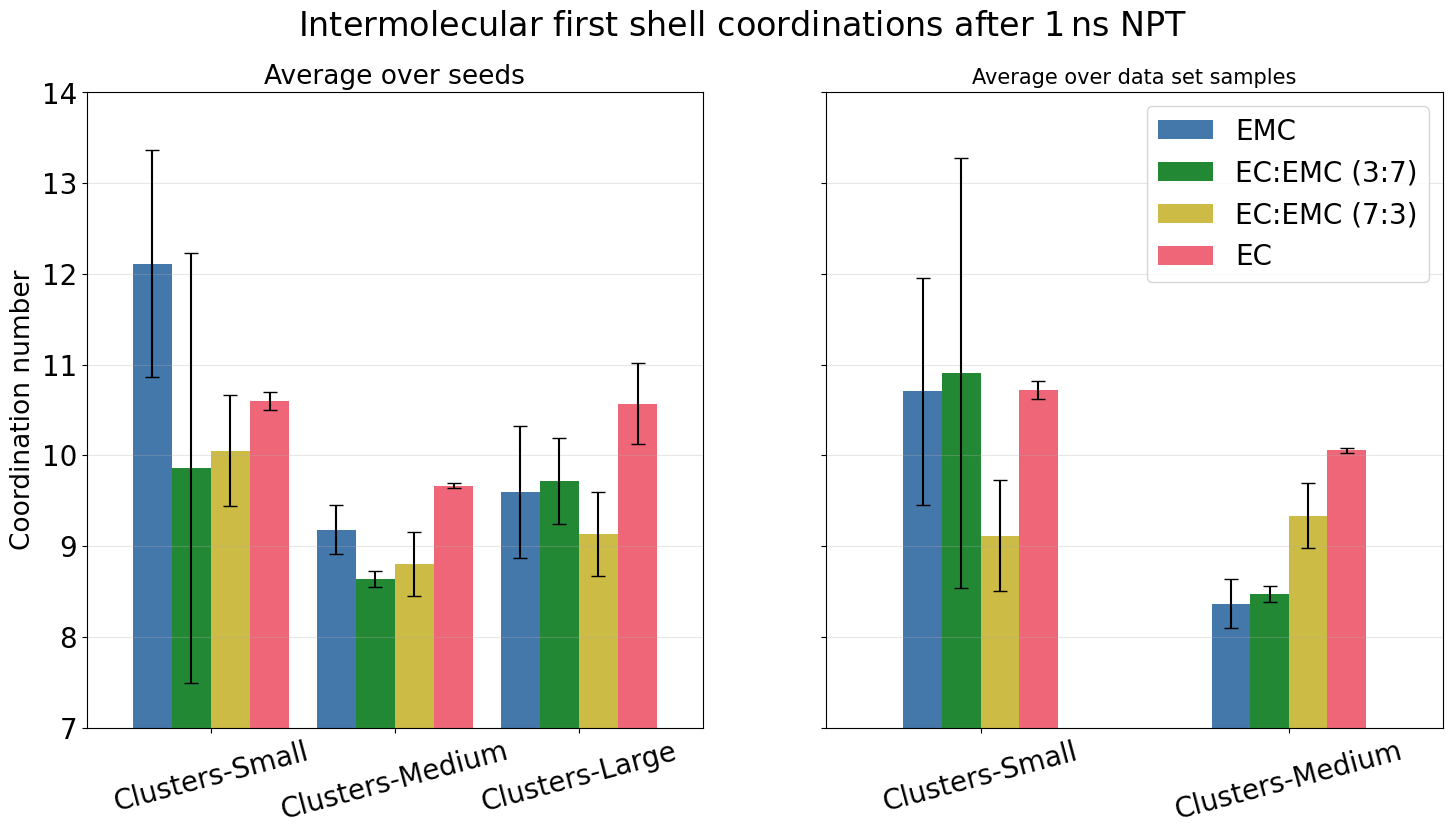

In [28]:

order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7*scale,3.3*scale), sharey=True)

fig.suptitle('Intermolecular first shell coordinations after 1$\\,$ns NPT')
seed_avg_df = seed_cn_agg_df.pivot(
	index='Data set',
	columns='Composition',
	values='mean_value',
).sort_index(axis=0,ascending=False)[order]
seed_std_df = seed_cn_agg_df.pivot(
	index='Data set',
	columns='Composition',
	values='std_value',
).sort_index(axis=0,ascending=False)[order]
seed_avg_df.plot.bar(
    ax=ax1,
    color=[funcs.get_colour(o) for o in order],
    ylim=[7,14],
    yerr=seed_std_df,
    capsize=5,
    rot=15,
    legend=False,
    xlabel='',
    width=0.85,
)
ax1.set_title('Average over seeds', fontsize=fsize-1)
ax1.set_ylabel('Coordination number', fontsize=fsize-1)
ax1.grid(axis='y', alpha=0.3)


sample_avg_df = sample_cn_agg_df.pivot(
	index='Data set',
	columns='Composition',
	values='mean_value',
).sort_index(axis=0,ascending=False)[order]
sample_std_df = sample_cn_agg_df.pivot(
	index='Data set',
	columns='Composition',
	values='std_value',
).sort_index(axis=0,ascending=False)[order]

sample_avg_df.plot.bar(
    ax=ax2,
    color=[funcs.get_colour(o) for o in order],
    yerr=seed_std_df,
    capsize=5,
    rot=15,
    legend=False,
    xlabel='',
    width=0.5,
)
ax2.set_title('Average over data set samples', fontsize=fsize-5)
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

#plt.savefig('../publication/plots/SI/part2_first-shell-cn.pdf', format='pdf', dpi=1200)

Average (std.) first shell coordinations:
Clusters-Large: R: 7.34 (0.24), CN: 9.67 (1.00)
Clusters-Medium: R: 7.59 (0.46), CN: 9.18 (0.48)
Clusters-Small: R: 7.59 (0.59), CN: 11.16 (1.18)


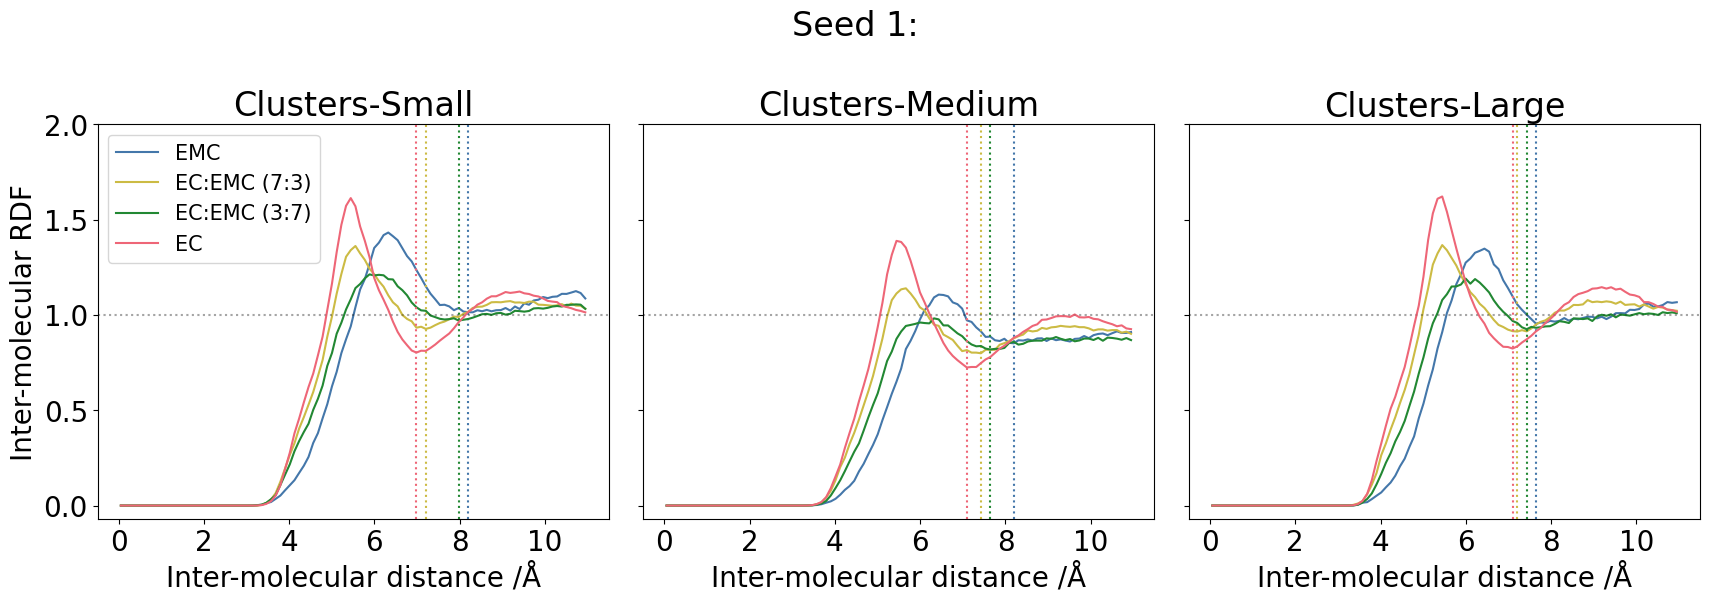

In [29]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,3, figsize=(7*scale,2.5*scale), sharey=True)
fig.suptitle('Seed 1:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    training_data = model.split('_')[0]
    ax.set_title(training_data)
    
    ax.set_xlabel('Inter-molecular distance /Å')
    for dset,seeds in dsets.items():       
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    for comp, (g, r) in comps.items():
                        if comp == 'EC': temp = 313
                        else: temp = 298

                        id0 = np.where(r>rstart)[0][0]
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])

                        ax.axvline(r[id0+idx], 0, 1, color=funcs.get_colour(comp), alpha=1, linestyle='dotted')
                        ax.plot(r, g, label=comp, color=funcs.get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color='black', alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([training_data, functional, seed, dset, comp, temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-5)
plt.tight_layout()


radii_df = pd.DataFrame(radii, columns=['Data set', 'Functional', 'Seed ID', 'Sample ID', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df = radii_df.drop('Seed ID', axis=1)
radii_df = radii_df.drop('Sample ID', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Data set'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

Average (std.) first shell coordinations:
Clusters-Large: R: 7.54 (0.47), CN: 9.76 (0.61)
Clusters-Medium: R: 7.51 (0.45), CN: 8.91 (0.52)
Clusters-Small: R: 7.59 (0.44), CN: 10.23 (0.69)


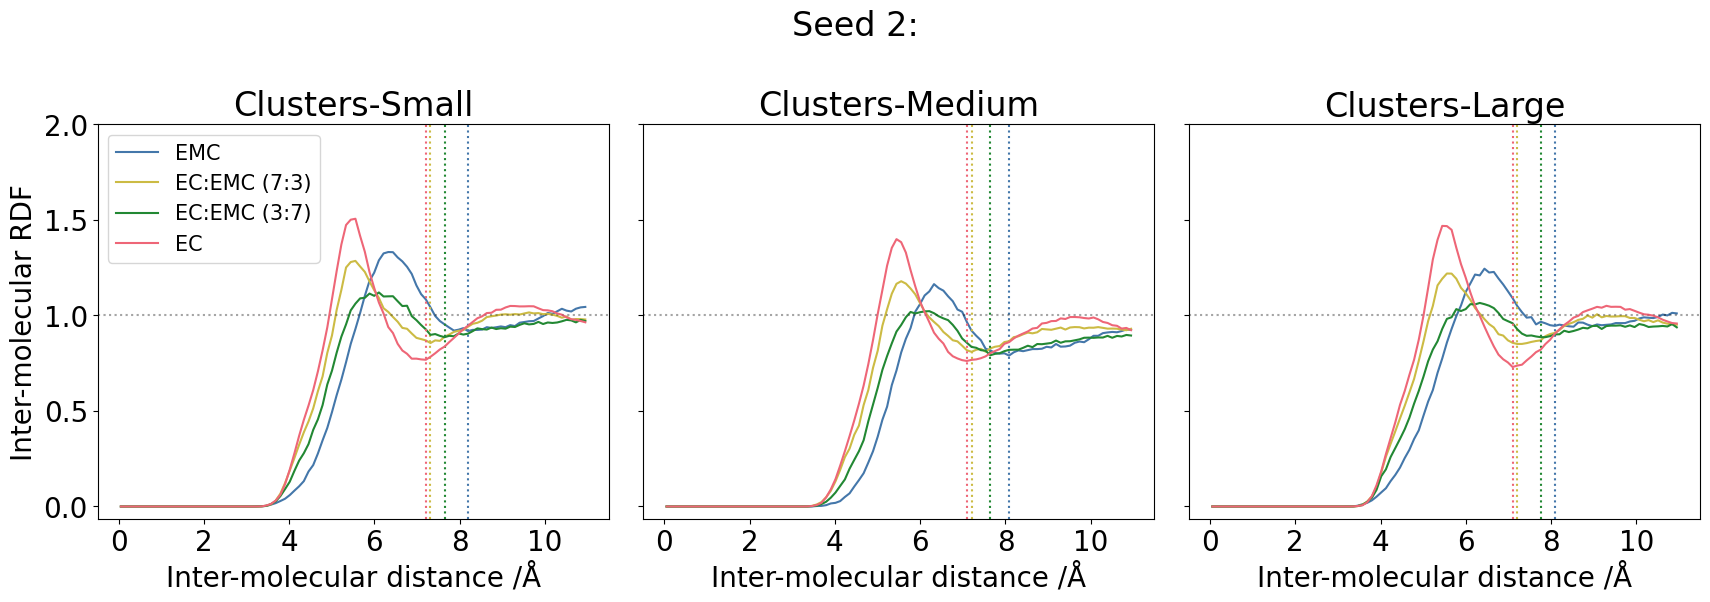

In [30]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,3, figsize=(7*scale,2.5*scale), sharey=True)
fig.suptitle('Seed 2:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    training_data = model.split('_')[0]
    ax.set_title(training_data)
    ax.set_xlabel('Inter-molecular distance /Å')
    for dset,seeds in dsets.items():
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED2':
                    for comp, (g, r) in comps.items():
                        if comp == 'EC': temp = 313
                        else: temp = 298

                        id0 = np.where(r>rstart)[0][0]                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])

                        ax.axvline(r[id0+idx], 0, 1, color=funcs.get_colour(comp), alpha=1, linestyle='dotted')
                        ax.plot(r, g, label=comp, color=funcs.get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color='black', alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([training_data, functional, seed, dset, comp, temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-5)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Data set', 'Functional', 'Seed ID', 'Sample ID', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df = radii_df.drop('Seed ID', axis=1)
radii_df = radii_df.drop('Sample ID', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Data set'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

Average (std.) first shell coordinations:
Clusters-Large: R: 7.59 (0.53), CN: 9.83 (0.68)
Clusters-Medium: R: 7.56 (0.48), CN: 9.12 (0.46)
Clusters-Small: R: 7.23 (0.60), CN: 10.58 (2.39)


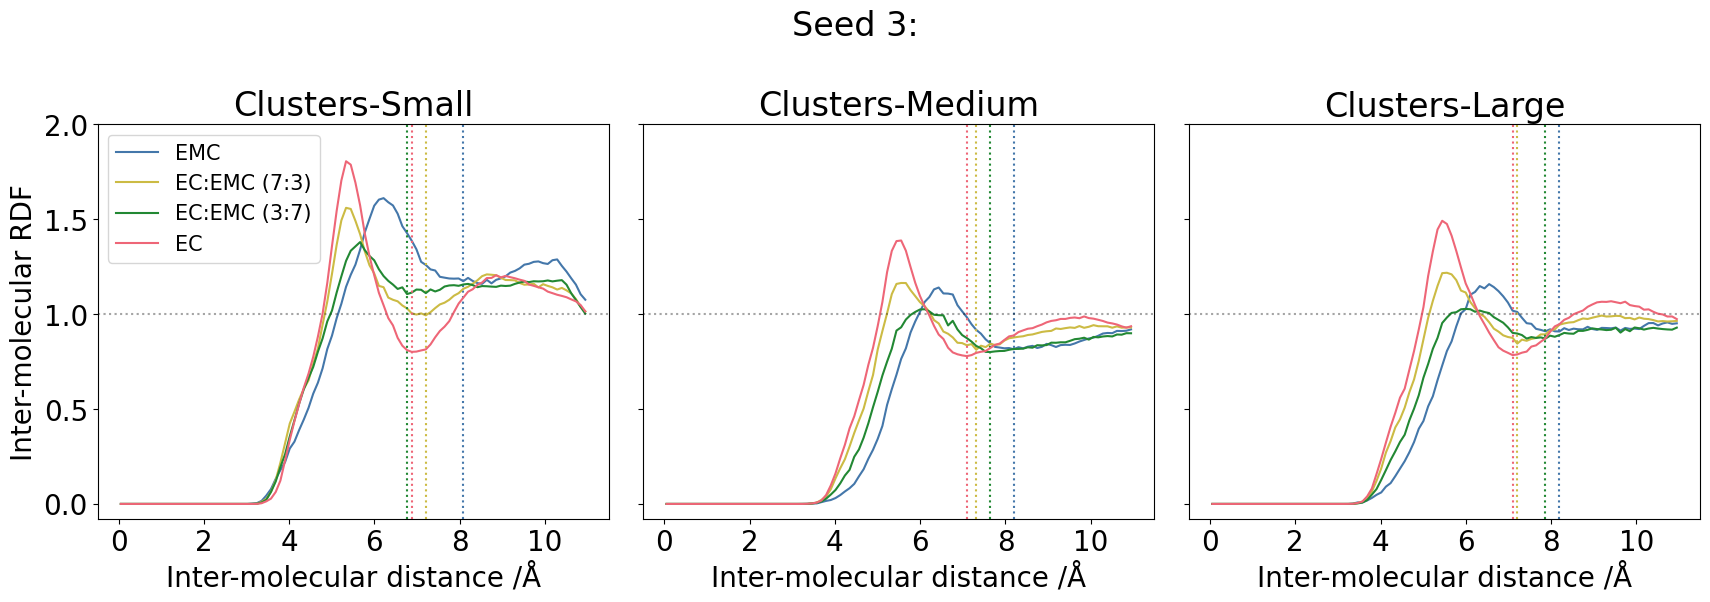

In [31]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,3, figsize=(7*scale,2.5*scale), sharey=True)
fig.suptitle('Seed 3:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    training_data = model.split('_')[0]
    ax.set_title(training_data)
    ax.set_xlabel('Inter-molecular distance /Å')
    for dset,seeds in dsets.items():
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED3':
                    for comp, (g, r) in comps.items():
                        if comp == 'EC': temp = 313
                        else: temp = 298

                        id0 = np.where(r>rstart)[0][0]                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])

                        ax.axvline(r[id0+idx], 0, 1, color=funcs.get_colour(comp), alpha=1, linestyle='dotted')
                        ax.plot(r, g, label=comp, color=funcs.get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color='black', alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([training_data, functional, seed, dset, comp, temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-5)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Data set', 'Functional', 'Seed ID', 'Sample ID', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df = radii_df.drop('Seed ID', axis=1)
radii_df = radii_df.drop('Sample ID', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Data set'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

Average (std.) first shell coordinations:
Clusters-Medium: R: 7.45 (0.24), CN: 9.41 (0.86)
Clusters-Small: R: 7.45 (0.44), CN: 10.48 (1.10)


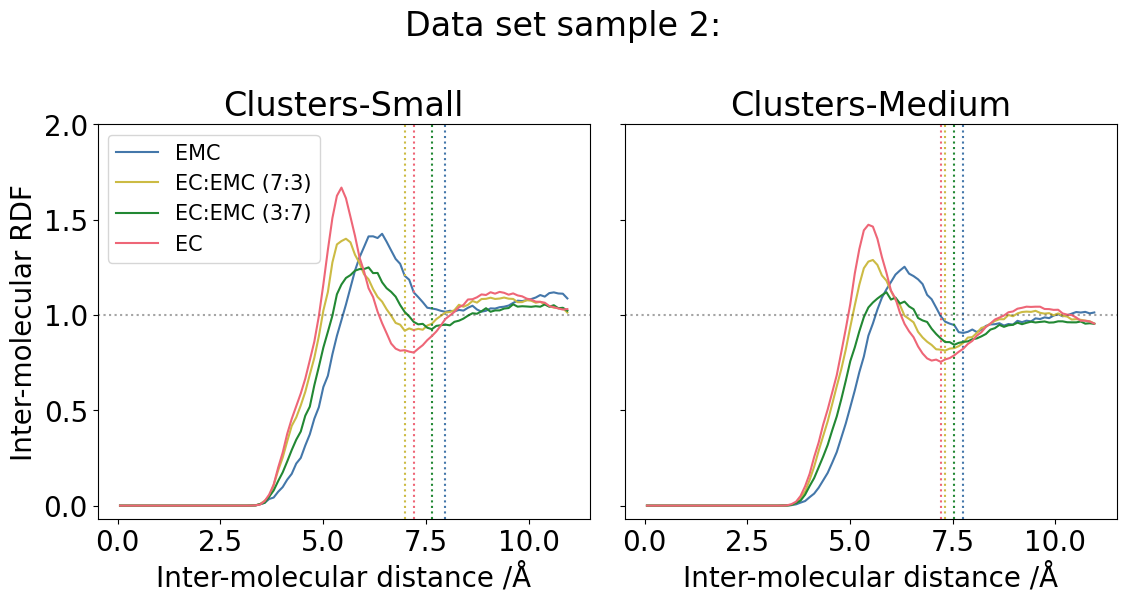

In [32]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,2, figsize=(14/3*scale,2.5*scale), sharey=True)
fig.suptitle('Data set sample 2:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    training_data = model.split('_')[0]
    ax.set_title(training_data)
    ax.set_xlabel('Inter-molecular distance /Å')
    for dset,seeds in dsets.items():
        if dset == 'DSET2':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    for comp, (g, r) in comps.items():
                        if comp == 'EC': temp = 313
                        else: temp = 298

                        id0 = np.where(r>rstart)[0][0]                       
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])

                        ax.axvline(r[id0+idx], 0, 1, color=funcs.get_colour(comp), alpha=1, linestyle='dotted')
                        ax.plot(r, g, label=comp, color=funcs.get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color='black', alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([training_data, functional, seed, dset, comp, temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-5)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Data set', 'Functional', 'Seed ID', 'Sample ID', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df = radii_df.drop('Seed ID', axis=1)
radii_df = radii_df.drop('Sample ID', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Data set'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

Average (std.) first shell coordinations:
Clusters-Medium: R: 7.48 (0.19), CN: 8.59 (1.30)
Clusters-Small: R: 7.29 (0.35), CN: 9.44 (0.68)


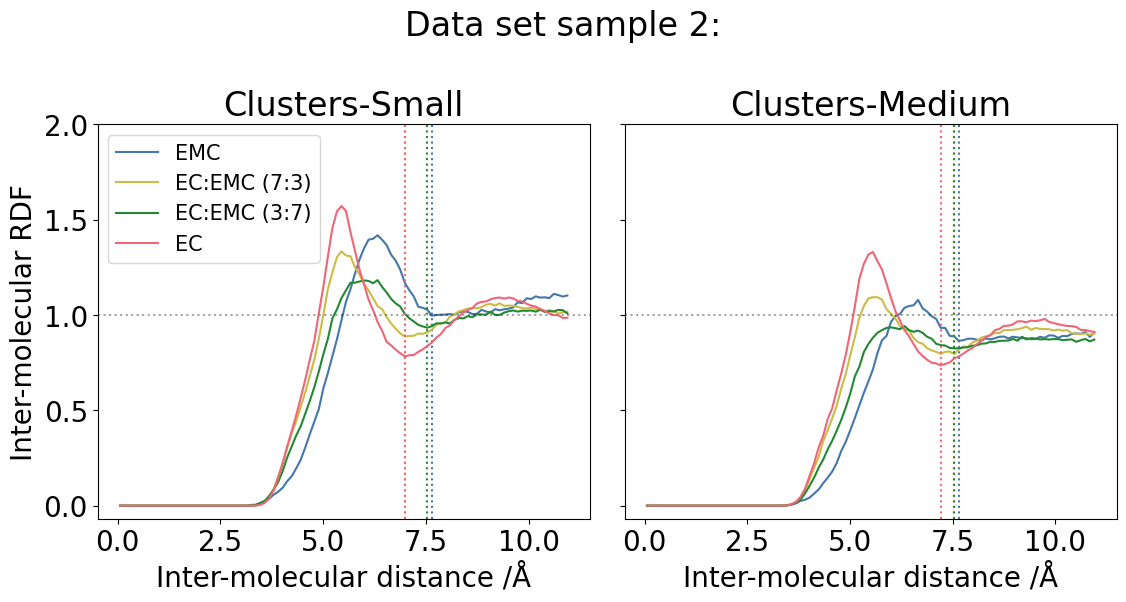

In [33]:
rstart = 6
id_width = 20

radii = []
fig, axs = plt.subplots(1,2, figsize=(14/3*scale,2.5*scale), sharey=True)
fig.suptitle('Data set sample 2:')
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    training_data = model.split('_')[0]
    ax.set_title(training_data)
    ax.set_xlabel('Inter-molecular distance /Å')
    for dset,seeds in dsets.items():
        if dset == 'DSET3':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    for comp, (g, r) in comps.items():
                        if comp == 'EC': temp = 313
                        else: temp = 298
                                                
                        id0 = np.where(r>rstart)[0][0]
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])

                        ax.axvline(r[id0+idx], 0, 1, color=funcs.get_colour(comp), alpha=1, linestyle='dotted')
                        ax.plot(r, g, label=comp, color=funcs.get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color='black', alpha=0.1)

                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, functional = model.split('_')
                        radii.append([training_data, functional, seed, dset, comp, temp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-5)
plt.tight_layout()

radii_df = pd.DataFrame(radii, columns=['Data set', 'Functional', 'Seed ID', 'Sample ID', 'Composition', 'Temperature', 'Rmin', 'CN'])
radii_df = radii_df.drop('Seed ID', axis=1)
radii_df = radii_df.drop('Sample ID', axis=1)
radii_df = radii_df.drop('Temperature', axis=1)
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Data set'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')

In [34]:
print('finished!')

finished!
